# ST1504 CA2 Part A: CIFAR-10 Image Generation

## Objective

The objective of this project is to build and evaluate a generative deep learning model capable of generating CIFAR-10 images.

The CIFAR-10 dataset contains 60,000 colour images of size 32 × 32 pixels across 10 classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In this project, a Variational Autoencoder (VAE) / Generative Adversarial Network (GAN) will be trained to generate new images that resemble the original CIFAR-10 dataset.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [74]:
from tensorflow.keras.datasets import cifar10
import pickle
import numpy as np
import os

dataset_path = "cifar-10-batches-py"


def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels

In [75]:
x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    batch_path = os.path.join(
        dataset_path,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    x_train_batches.append(images)
    y_train_batches.append(labels)

x_train = np.concatenate(x_train_batches)
y_train = np.concatenate(y_train_batches)

x_test, y_test = load_cifar_batch(
    os.path.join(dataset_path, "test_batch")
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


# Exploratory Data Analysis (EDA)

### Dataset Structure

The CIFAR-10 training dataset contains **50000 images**, while the testing dataset contains **10000 images**. Each image has dimensions of **32 × 32 pixels** with **3 colour channels**, representing red, green and blue (RGB).

The images are stored using the `uint8` datatype, with pixel intensities ranging from **0 to 255**. Therefore, the pixel values will need to be normalised before they are used to train the generative model.

In [76]:
# 1. Inspect the dataset structure
print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)

print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training image shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


### Class distribution analysis

The class-distribution graph shows that each of the ten classes contains **5000 training images**. This means that the CIFAR-10 training dataset is equally balanced.

As no class is overrepresented or underrepresented, techniques such as oversampling or undersampling are not required. The balanced distribution should allow the model to learn from an equal number of examples from every class.

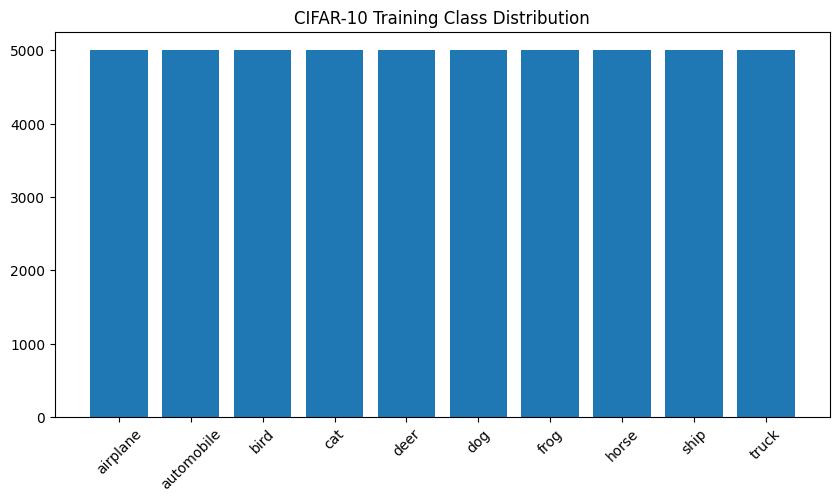

In [77]:
class_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Visual Inspection of CIFAR-10 Images

A random sample of 25 training images was displayed to understand the visual characteristics of the dataset. The images contain considerable variation in backgrounds, positions and colours.

Although the objects are generally recognisable, their small resolution of **32 × 32 pixels** means that some details appear pixelated. This suggests that the generative model will need to learn the main shapes, colours and visual patterns of each class rather than fine details.



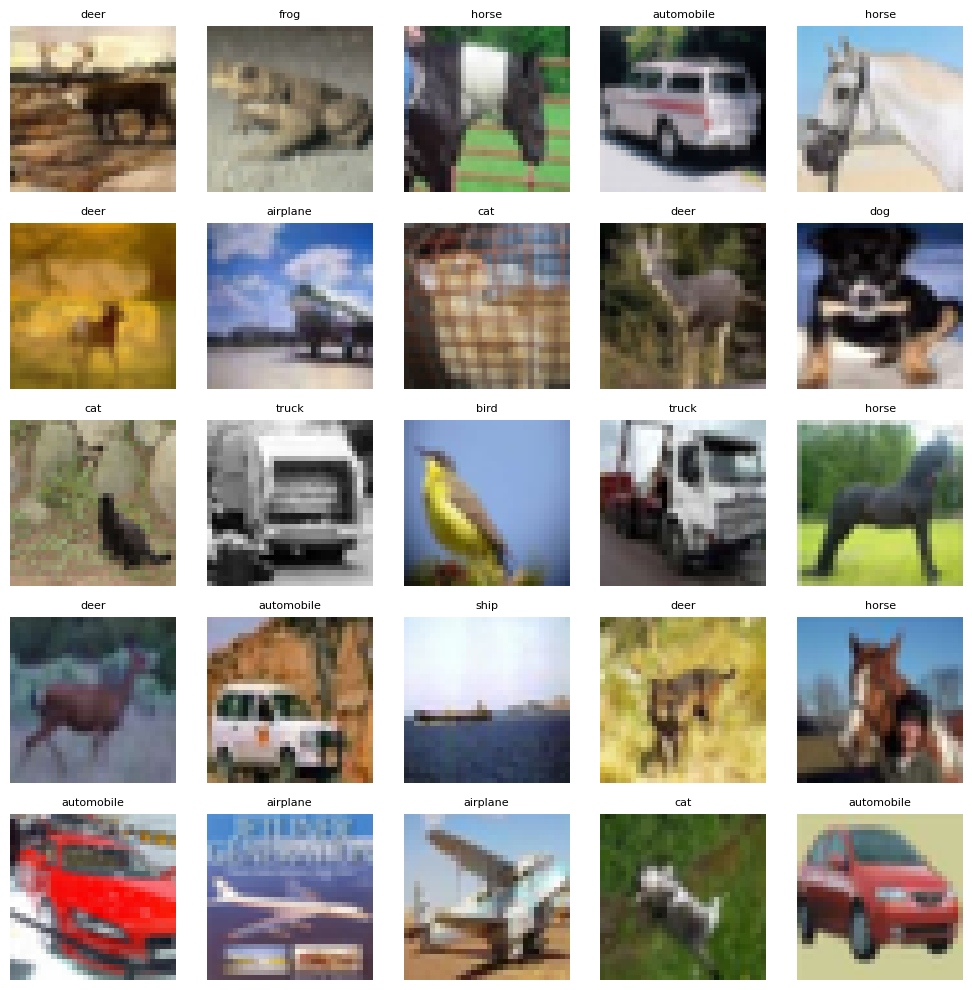

In [78]:
# 5x5 Grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, x_train.shape[0])
    ax.imshow(x_train[idx])
    ax.axis('off')
    ax.set_title(class_names[y_train[idx]], fontsize=8)
plt.tight_layout()
plt.show()

### Distribution of RGB Pixel Intensities

The histogram displays the distributions of pixel intensities for the red, green and blue channels. The three channels cover a wide range of intensity values and show overlapping distributions.

This confirms that colour information is an important feature of the dataset. Therefore, all three RGB channels will be retained instead of converting the images to grayscale for the main model.

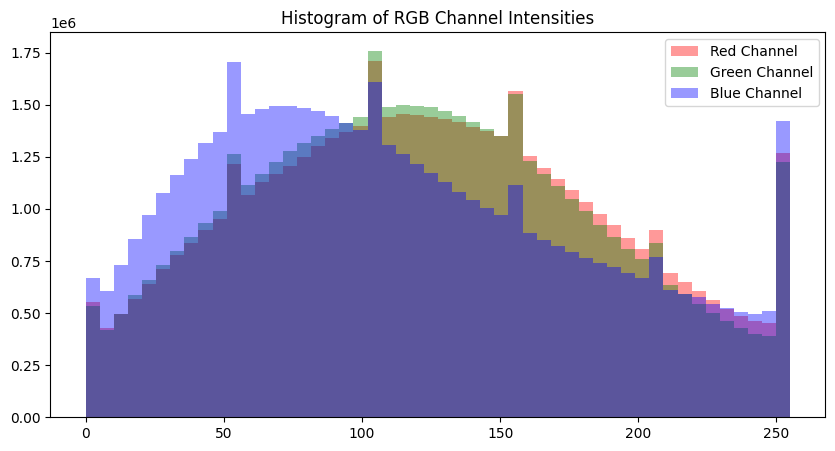

In [79]:
# RGB Histograms
plt.figure(figsize=(10, 5))
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(x_train[:, :, :, i].flatten(), bins=50, color=color, alpha=0.4, label=f'{color.capitalize()} Channel')
plt.title("Histogram of RGB Channel Intensities")
plt.legend()
plt.show()

### Data Cleaning 

The dataset was checked for missing and infinite pixel values. A total of **0 missing values** and **0 infinite values** were detected.

Therefore, no imputation or removal of images is required. The dataset can be retained in its original form before normalisation.

In [80]:
# Check for issues
print("Missing values:", np.isnan(x_train).sum())
print("Infinite values:", np.isinf(x_train).sum())


Missing values: 0
Infinite values: 0


### Variance Analysis (Inspection of Low-Contrast Images)

Pixel variance was calculated for each image to identify images with limited differences in colour or brightness. The five images with the lowest variance were then visually inspected.

The selected images appeared recognisable and mainly contained simple objects against relatively plain or uniform backgrounds. This shows that low pixel variance does not automatically indicate that an image is corrupted. Therefore, these images will be retained because they are still valid CIFAR-10 samples.

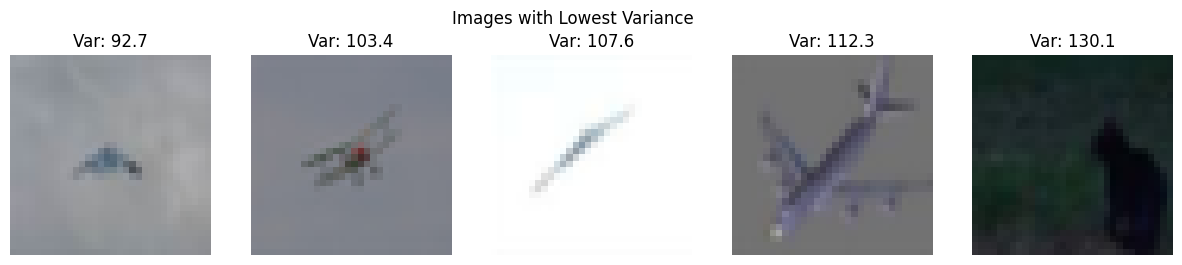

In [81]:
image_variances = x_train.var(axis=(1, 2, 3))
low_var_indices = np.argsort(image_variances)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(low_var_indices):
    axes[i].imshow(x_train[idx])
    axes[i].set_title(f"Var: {image_variances[idx]:.1f}")
    axes[i].axis('off')
plt.suptitle("Images with Lowest Variance")
plt.show()

### Comparison of Training and Testing Distributions

Each class contains **5000 training samples** and **1000 testing samples**. Both datasets therefore have the same balanced class distribution.

This makes the testing set suitable for evaluating the model because its class composition is consistent with the training set. The testing images will be kept separate and will not be used for model training.

In [82]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
print("Training counts:", train_counts)
print("Test counts:", test_counts)

Training counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Average Within-Image Pixel Variance by Class

The graph compares the average within-image pixel variance across the ten CIFAR-10 classes. The truck class has the highest average variance, while the deer class has the lowest. A higher pixel variance indicates that images within the class generally contain greater differences in colour, brightness or contrast.

However, this measurement does not directly show that trucks are harder to generate than deer. The difficulty of generating each class will be evaluated later by visually inspecting the generated images and comparing class-specific evaluation results, such as manual acceptance rates and Fréchet Inception Distance (FID).

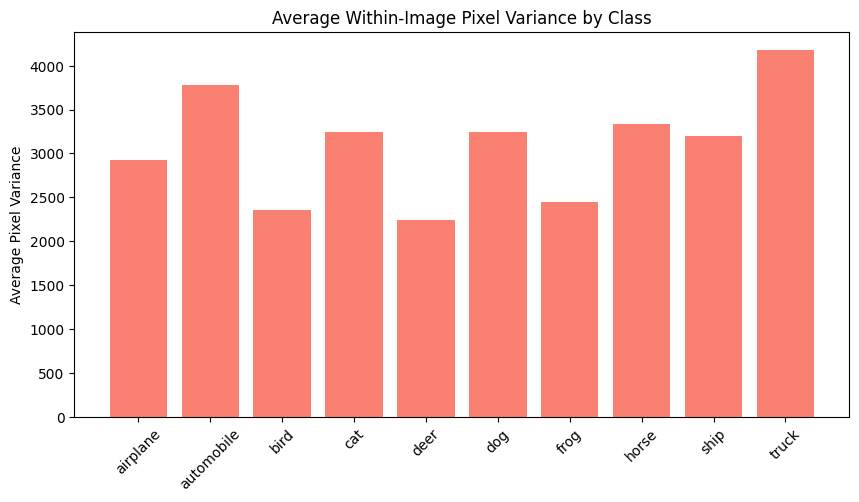

In [83]:
# Calculate variance for each image, then group by class
class_variances = []
for i in range(10):
    class_images = x_train[y_train == i]
    # Variance of each image, then mean of those variances
    avg_var = np.mean(np.var(class_images, axis=(1, 2, 3)))
    class_variances.append(avg_var)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_variances, color='salmon')
plt.title("Average Within-Image Pixel Variance by Class")
plt.ylabel("Average Pixel Variance")
plt.xticks(rotation=45)
plt.show()

### Mean Image for Each Class

A mean image was created by averaging all the training images belonging to each class. The resulting images show faint differences in the typical colours, backgrounds and object positions associated with each class. For example, the ship class generally has a blue-grey background, while vehicle classes such as automobiles and trucks contain darker areas around the lower-middle portion of the image.

However, all the mean images appear blurred because objects within the same class differ in position, size, colour, viewing angle and background. This demonstrates that there is considerable visual diversity within each class, which the generative model will need to learn.

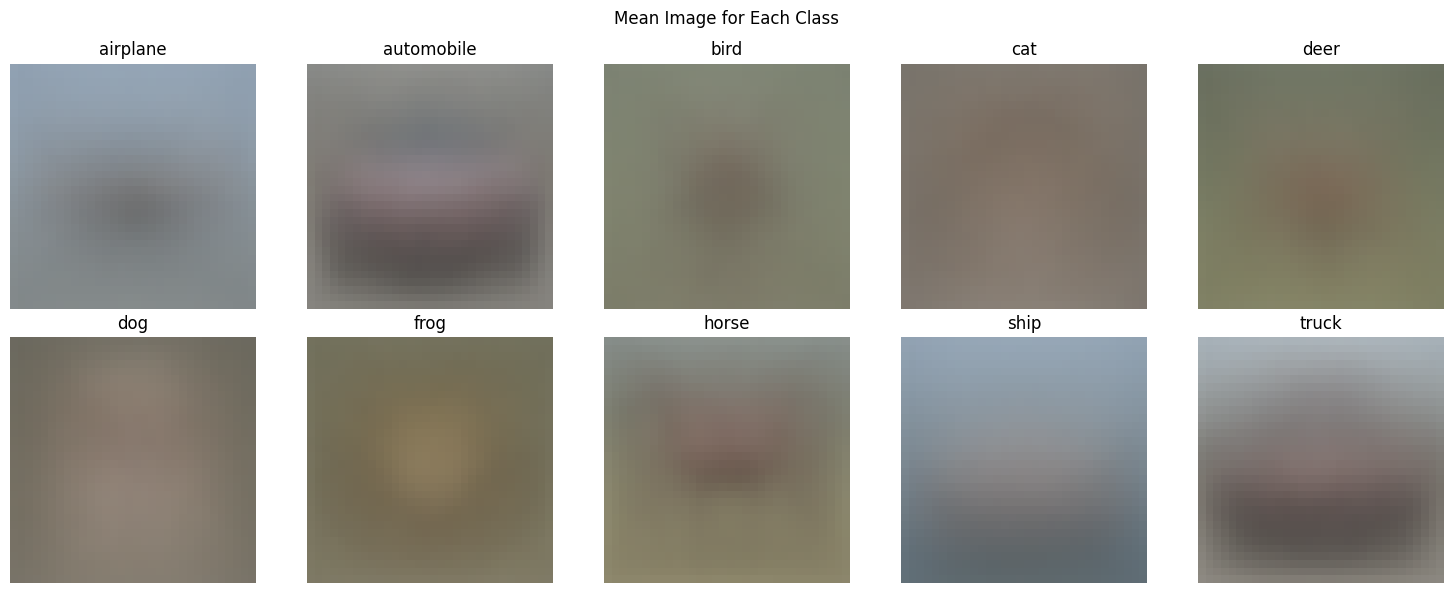

In [84]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    class_images = x_train[y_train == i]
    mean_img = np.mean(class_images, axis=0).astype('uint8')
    axes[i].imshow(mean_img)
    axes[i].set_title(class_names[i])
    axes[i].axis('off')
plt.suptitle("Mean Image for Each Class")
plt.tight_layout()
plt.show()

### RGB and Grayscale Comparison

Converting an RGB image to grayscale reduces it from three colour channels to one channel and removes its colour information. Generating grayscale images may be easier because the model has fewer pixel values and colour relationships to learn. This may also reduce the model's computational requirements.

However, colour provides useful visual information for distinguishing certain objects and backgrounds. Removing colour could make some generated objects less recognisable even if their overall shapes are preserved. Since the main task involves generating coloured CIFAR-10 images, RGB images will be retained for model training. Grayscale generation could instead be investigated as a separate experiment.

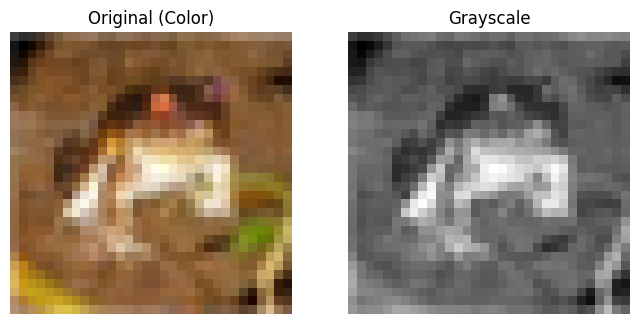

In [85]:
# Convert to grayscale by averaging channels
x_train_gray = np.mean(x_train, axis=3, keepdims=True)

# Compare shapes and visualize
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0])
plt.title("Original (Color)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_train_gray[0].reshape(32, 32), cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

### Image-Shape Consistency

All training images were found to have the same dimensions of 32 × 32 × 3. No malformed images or inconsistent image dimensions were detected.

Therefore, resizing, cropping and padding are not required before model training. Maintaining the original dimensions also ensures that no visual information is unnecessarily removed or distorted.

In [86]:
# Check for consistent image shapes
shapes = [img.shape for img in x_train]
unique_shapes = np.unique(shapes, axis=0)

if len(unique_shapes) == 1:
    print(f"All images have a consistent shape of: {unique_shapes[0]}")
else:
    print("Warning: Dataset contains inconsistent image shapes:", unique_shapes)        

All images have a consistent shape of: [32 32  3]


## Data Preprocessing

The exploratory data analysis found no missing values, corrupted images, inconsistent dimensions or class imbalance. Therefore, no image removal, resizing or class rebalancing was required.

The class labels were converted into one-dimensional integer arrays. The original training dataset was then divided into training and validation subsets using a 90:10 ratio. Stratified splitting was applied to preserve the balanced class distribution across all ten classes. The official testing dataset was kept separate for final model evaluation.

Image conversion, pixel normalisation, batching and possible augmentation will be performed during the modelling stage because their implementation depends on the selected generative architecture.

### Prepare the Labels

In [87]:
# Convert labels into one-dimensional integer arrays
y_train_processed = y_train.astype("int32").reshape(-1)
y_test_processed = y_test.astype("int32").reshape(-1)

print("Training labels:", y_train_processed.shape)
print("Testing labels:", y_test_processed.shape)
print("Label datatype:", y_train_processed.dtype)

Training labels: (50000,)
Testing labels: (10000,)
Label datatype: int32


### Create Validation Dataset

In [88]:
from sklearn.model_selection import train_test_split

x_model_train, x_val, y_model_train, y_val = train_test_split(
    x_train,
    y_train_processed,
    test_size=0.10,
    random_state=42,
    stratify=y_train_processed
)

In [89]:
print("Model-training images:", x_model_train.shape)
print("Validation images:", x_val.shape)
print("Testing images:", x_test.shape)

print("Model-training labels:", y_model_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels:", y_test_processed.shape)

print("Image datatype:", x_model_train.dtype)
print("Minimum pixel value:", x_model_train.min())
print("Maximum pixel value:", x_model_train.max())

Model-training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Model-training labels: (45000,)
Validation labels: (5000,)
Testing labels: (10000,)
Image datatype: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [90]:
print(
    "Training samples per class:",
    np.bincount(y_model_train, minlength=10)
)

print(
    "Validation samples per class:",
    np.bincount(y_val, minlength=10)
)

print(
    "Testing samples per class:",
    np.bincount(y_test_processed, minlength=10)
)

Training samples per class: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
Validation samples per class: [500 500 500 500 500 500 500 500 500 500]
Testing samples per class: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Verify the processed images

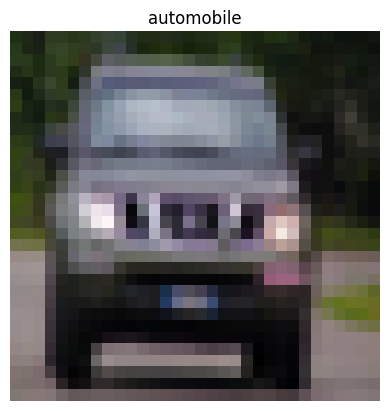

In [91]:
plt.imshow(x_model_train[0])
plt.title(class_names[y_model_train[0]])
plt.axis("off")
plt.show()

# IM DOING VAE - JUN HAO

In [92]:
# 1. Ensure labels are 1D integer arrays (useful for later evaluation/visualization)
y_train_processed = y_train.astype("int32").reshape(-1)
y_test_processed = y_test.astype("int32").reshape(-1)

# 2. Train/Validation Split (keeping stratification so classes are balanced)
from sklearn.model_selection import train_test_split

x_model_train, x_val, y_model_train, y_val = train_test_split(
    x_train,
    y_train_processed,
    test_size=0.10,
    random_state=42,
    stratify=y_train_processed
)


x_model_train = x_model_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')


x_model_train = x_model_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

print("VAE Preprocessing complete.")
print("Min pixel value:", x_model_train.min()) # 0.0
print("Max pixel value:", x_model_train.max()) # 0.1

print("Preprocessing complete.")
print("Min pixel value:", x_model_train.min()) 
print("Max pixel value:", x_model_train.max()) 

# 5. Batching with tf.data.Dataset for VAE
# A VAE takes an image as both input and target (autoencoder architecture), 
# so your dataset yields tuples of (image, image) OR just the image depending on your model design.
batch_size = 128

# Option A: Yielding just images (if your custom training step handles targets)
train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_model_train)
    .shuffle(buffer_size=len(x_model_train))
    .batch(batch_size, drop_remainder=True)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(x_val)
    .batch(batch_size, drop_remainder=True)
)

# Option B: If using standard model.fit() with a custom VAE class, 
# you often pass (x_model_train, x_model_train) because the model reconstructs its own input.
train_dataset_autoencoder = (
    tf.data.Dataset.from_tensor_slices((x_model_train, x_model_train))
    .shuffle(buffer_size=len(x_model_train))
    .batch(batch_size, drop_remainder=True)
)

VAE Preprocessing complete.
Min pixel value: 0.0
Max pixel value: 1.0
Preprocessing complete.
Min pixel value: 0.0
Max pixel value: 1.0


encoder, decoder

In [93]:
from tensorflow.keras import layers, models
import tensorflow as tf

latent_dim = 5  # Size of the latent space vector

# --- 1. ENCODER ARCHITECTURE ---
encoder_inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# VAE outputs two values for the latent space: mean (z_mean) and log-variance (z_log_var)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# --- REPARAMETERIZATION TRICK ---
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


# --- 2. DECODER ARCHITECTURE ---
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# Decoder output layer (using 'tanh' because your images are normalized to [-1, 1])
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="tanh", padding="same")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

print("VAE Encoder and Decoder successfully defined.")

VAE Encoder and Decoder successfully defined.


In [94]:
from tensorflow import keras

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        
        # Trackers for monitoring training progress
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction


    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [95]:
# Instantiate the VAE model
vae = VAE(encoder, decoder)

# Compile with an optimizer (Adam is standard)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005))

# Fit the model using your [0, 1] normalized train dataset
history = vae.fit(
    train_dataset, 
    epochs=30, 
    validation_data=val_dataset
)

vae.save_weights("vae_baseline_weights.h5")

Epoch 1/30
351/351 [==============================] - 6s 14ms/step - loss: 820.1302 - reconstruction_loss: 801.6973 - kl_loss: 18.4330 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00
Epoch 2/30
351/351 [==============================] - 5s 13ms/step - loss: 672.7991 - reconstruction_loss: 663.8293 - kl_loss: 8.9699 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00
Epoch 3/30
351/351 [==============================] - 5s 13ms/step - loss: 662.1864 - reconstruction_loss: 653.0999 - kl_loss: 9.0862 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00
Epoch 4/30
351/351 [==============================] - 5s 13ms/step - loss: 657.3770 - reconstruction_loss: 648.1680 - kl_loss: 9.2094 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00
Epoch 5/30
351/351 [==============================] - 5s 13ms/step - loss: 655.5338 - reconstruction_loss: 646.6964

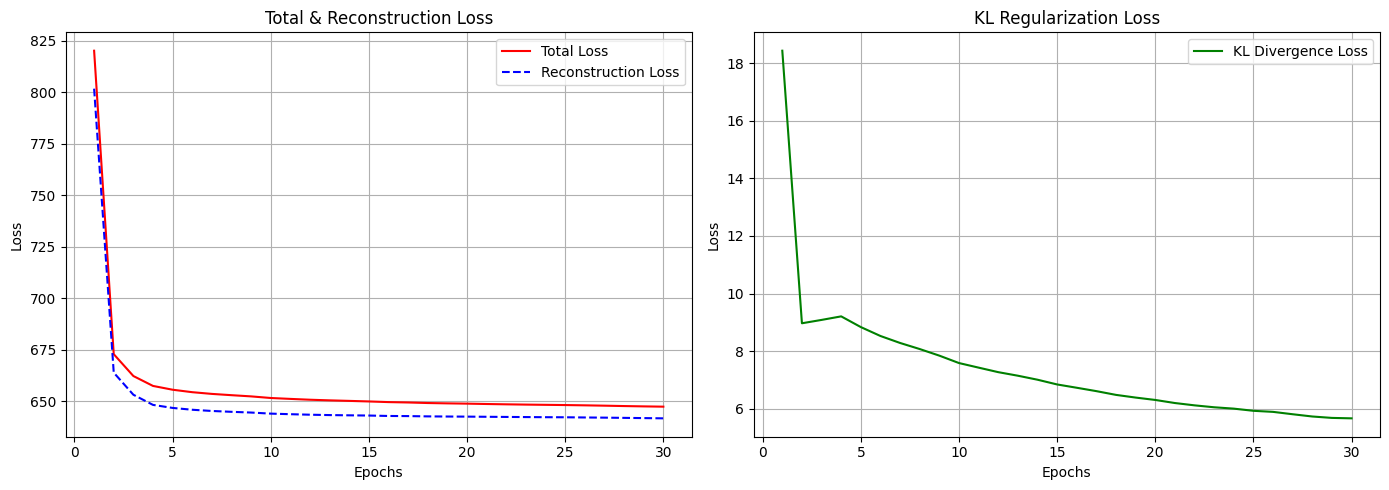

In [96]:
import matplotlib.pyplot as plt

# 1. Extract loss values from the history object
epochs = range(1, len(history.history['loss']) + 1)
total_loss = history.history['loss']
recon_loss = history.history['reconstruction_loss']
kl_loss = history.history['kl_loss']

# 2. Create the plot
plt.figure(figsize=(14, 5))

# Plot 1: Total Loss vs Reconstruction Loss (Since they are on similar scales)
plt.subplot(1, 2, 1)
plt.plot(epochs, total_loss, 'r-', label='Total Loss')
plt.plot(epochs, recon_loss, 'b--', label='Reconstruction Loss')
plt.title('Total & Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: KL Divergence Loss (Usually on a much smaller scale)
plt.subplot(1, 2, 2)
plt.plot(epochs, kl_loss, 'g-', label='KL Divergence Loss')
plt.title('KL Regularization Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 114ms/step


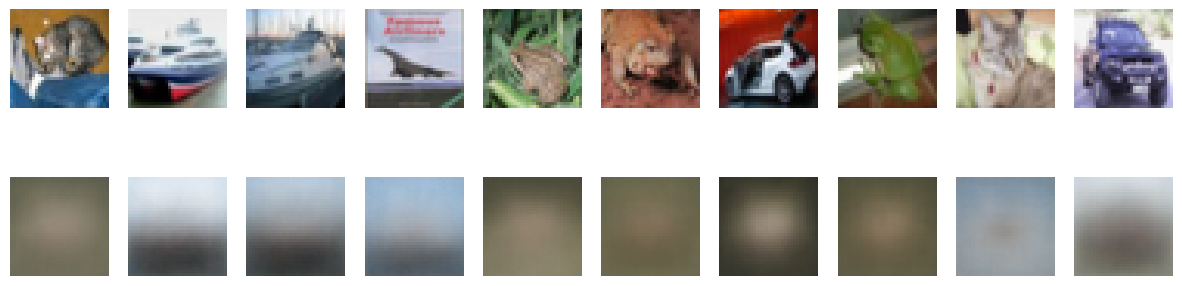

In [97]:
import matplotlib.pyplot as plt

z_mean, _, _ = vae.encoder.predict(x_test[:10], verbose=0)
reconstructed = vae.decoder.predict(z_mean)

plt.figure(figsize=(15,4))

for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, 10, i+11)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

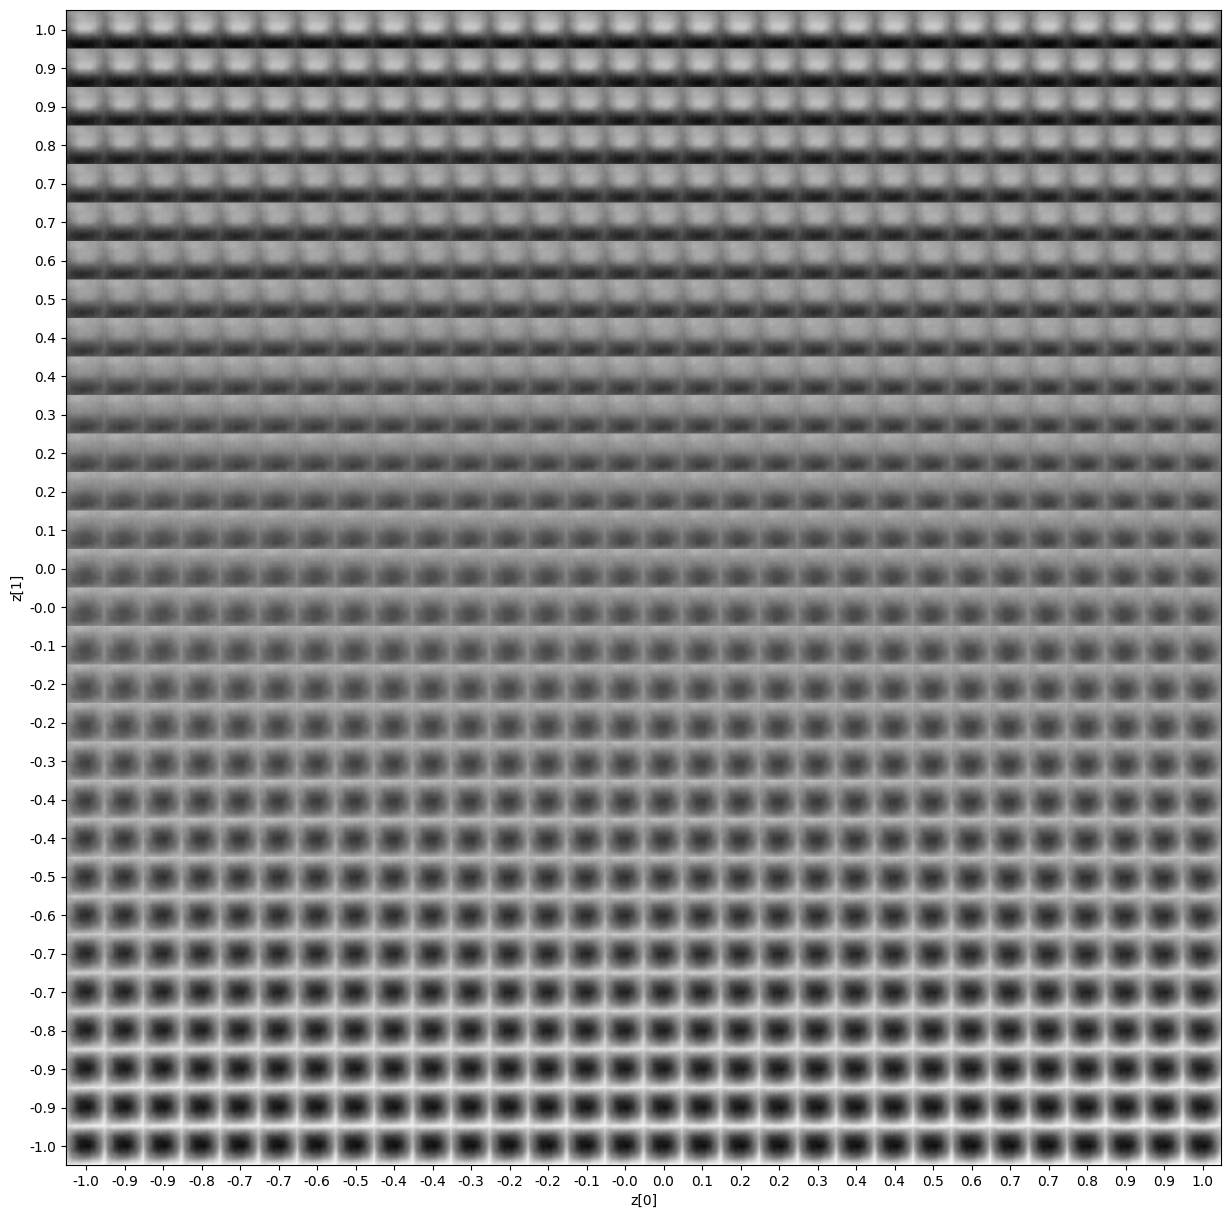

In [98]:
import numpy as np
import matplotlib.pyplot as plt

def plot_latent_space_cifar(vae, latent_dim=16, active_dims=(0, 1), n=30, figsize=15):
    image_size = 32  # CIFAR-10 size is 32x32
    scale = 1.0
    
    # We create a 2D grid for the image. Since CIFAR has 3 channels, we will store them or average them for a grayscale grid view.
    figure = np.zeros((image_size * n, image_size * n))
    
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.zeros((1, latent_dim))
            z_sample[0, active_dims[0]] = xi
            z_sample[0, active_dims[1]] = yi
            
            # Predict using decoder -> output shape is (1, 32, 32, 3)
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            
            # Take the first decoded image: shape (32, 32, 3)
            digit = x_decoded[0]
            
            # If using [-1, 1] or [0, 1] scaling, convert to 2D grayscale for this grid view 
            # by averaging the RGB channels, and rescale to [0, 1] for plotting
            digit = np.mean(digit, axis=-1) 
            if digit.min() < 0: # If using tanh [-1, 1]
                digit = (digit + 1.0) / 2.0
            
            figure[
                i * image_size : (i + 1) * image_size,
                j * image_size : (j + 1) * image_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = image_size // 2
    end_range = n * image_size + start_range
    pixel_range = np.arange(start_range, end_range, image_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel(f"z[{active_dims[0]}]")
    plt.ylabel(f"z[{active_dims[1]}]")
    plt.imshow(figure, cmap="gray")
    plt.show()

# Run it with your trained vae model
plot_latent_space_cifar(vae, latent_dim=latent_dim, active_dims=(0, 1))

## improved vae

In [108]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

latent_dim = 30  # Reduced latent space capacity

# Helper function for a Residual Block in the Encoder
def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    
    # Adjust shortcut dimension if stride changes
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.add([x, shortcut])
    return layers.Activation("relu")(x)

# --- ENCODER WITH RESIDUAL BLOCKS ---
encoder_inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(64, 3, strides=1, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Apply residual blocks with downsampling (stride=2)
x = residual_block(x, 128, stride=2) # 32x32 -> 16x16
x = residual_block(x, 256, stride=2) # 16x16 -> 8x8
x = residual_block(x, 512, stride=2) # 8x8 -> 4x4

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Reparameterization Trick
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


# --- DECODER WITH TRANSPOSE CONV & RESIDUALS ---
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(4 * 4 * 512, activation="relu")(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Reshape((4, 4, 512))(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x) # 4x4 -> 8x8
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x) # 8x8 -> 16x16
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)  # 16x16 -> 32x32
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

In [109]:
class AdvancedVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        
        self.beta = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # MSE + SSIM Hybrid Loss
            mse_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.mean_squared_error(data, reconstruction),
                    axis=(1, 2)
                )
            )
            ssim_loss = tf.reduce_mean(1.0 - tf.image.ssim(data, reconstruction, max_val=1.0))
            reconstruction_loss = mse_loss + (ssim_loss * 800.0)
            
            # KL Divergence with Free Bits
            kl_per_dim = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            free_bits = 0.5
            kl_per_dim_capped = tf.maximum(kl_per_dim, free_bits)
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_per_dim_capped, axis=1))
            
            total_loss = reconstruction_loss + (self.beta * kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

class KLAnnealingCallback(keras.callbacks.Callback):
    def __init__(self, start_epoch=5, end_epoch=30):
        super().__init__()
        self.start_epoch = start_epoch
        self.end_epoch = end_epoch

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start_epoch:
            beta_val = 0.0
        elif epoch >= self.end_epoch:
            beta_val = 1.0
        else:
            beta_val = float(epoch - self.start_epoch) / float(self.end_epoch - self.start_epoch)
        
        self.model.beta.assign(beta_val)
        print(f"\nEpoch {epoch+1}: Current KL Beta weight = {self.model.beta.numpy():.4f}")

    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["kl_beta"] = float(self.model.beta.numpy())

In [110]:
# class KLAnnealingCallback(keras.callbacks.Callback):
#     def __init__(self, start_epoch=5, end_epoch=30): 
#         super().__init__()
#         self.start_epoch = start_epoch
#         self.end_epoch = end_epoch

#     def on_epoch_begin(self, epoch, logs=None):
#         if epoch < self.start_epoch:
#             self.model.beta.assign(0.0)
#         elif epoch >= self.end_epoch:
#             self.model.beta.assign(1.0)
#         else:
#             beta_val = float(epoch - self.start_epoch) / float(self.end_epoch - self.start_epoch)
#             self.model.beta.assign(beta_val)
#         print(f"\nEpoch {epoch+1}: Current KL Beta weight = {self.model.beta.numpy():.4f}")

In [111]:
# Instantiate and compile
vae = AdvancedVAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003))

# Train
history = vae.fit(
    train_dataset,
    epochs=35,
    validation_data=val_dataset,
    callbacks=[KLAnnealingCallback(start_epoch=5, end_epoch=30)]
)

# Save your improved weights
vae.save_weights("vae_advanced_weights.h5")


Epoch 1: Current KL Beta weight = 0.0000
Epoch 1/35
351/351 [==============================] - 26s 67ms/step - loss: 499.6934 - reconstruction_loss: 499.6934 - kl_loss: 275.1262 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00 - kl_beta: 0.0000e+00

Epoch 2: Current KL Beta weight = 0.0000
Epoch 2/35
351/351 [==============================] - 23s 66ms/step - loss: 349.7340 - reconstruction_loss: 349.7340 - kl_loss: 324.3154 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00 - kl_beta: 0.0000e+00

Epoch 3: Current KL Beta weight = 0.0000
Epoch 3/35
351/351 [==============================] - 23s 66ms/step - loss: 334.0177 - reconstruction_loss: 334.0177 - kl_loss: 327.3873 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_kl_loss: 0.0000e+00 - kl_beta: 0.0000e+00

Epoch 4: Current KL Beta weight = 0.0000
Epoch 4/35
351/351 [==============================] - 23s 66ms/step - loss: 328.0008 - reconst

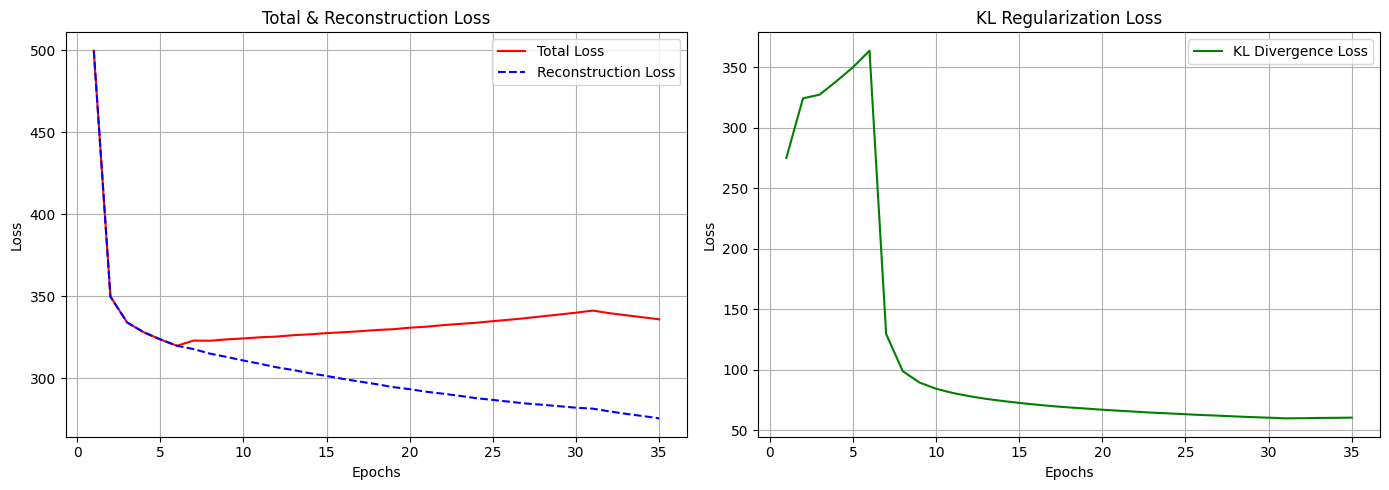

In [114]:
import matplotlib.pyplot as plt

# 1. Extract loss values from the history object
epochs = range(1, len(history.history['loss']) + 1)
total_loss = history.history['loss']
recon_loss = history.history['reconstruction_loss']
kl_loss = history.history['kl_loss']

# 2. Create the plot
plt.figure(figsize=(14, 5))

# Plot 1: Total Loss vs Reconstruction Loss (Since they are on similar scales)
plt.subplot(1, 2, 1)
plt.plot(epochs, total_loss, 'r-', label='Total Loss')
plt.plot(epochs, recon_loss, 'b--', label='Reconstruction Loss')
plt.title('Total & Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: KL Divergence Loss (Usually on a much smaller scale)
plt.subplot(1, 2, 2)
plt.plot(epochs, kl_loss, 'g-', label='KL Divergence Loss')
plt.title('KL Regularization Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

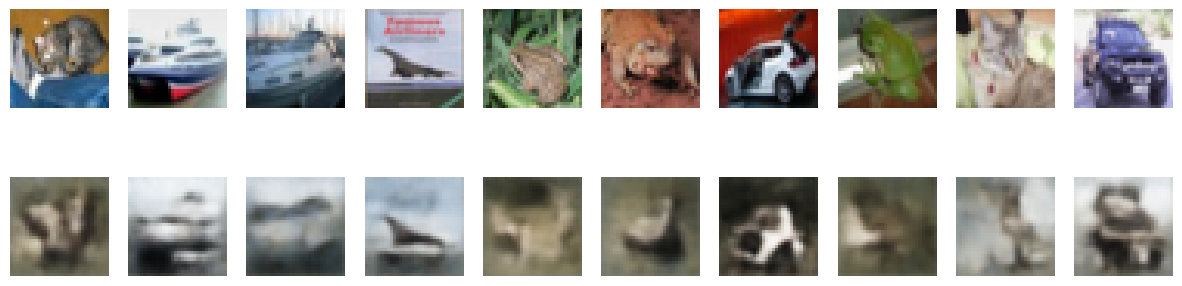

In [115]:
z_mean, _, _ = vae.encoder.predict(x_test[:10], verbose=0)
reconstructed = vae.decoder.predict(z_mean, verbose=0)

plt.figure(figsize=(15, 4))
for i in range(10):
    # Original (RGB)
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i]) # Removed squeeze/cmap to keep color
    plt.axis("off")

    # Reconstruction (RGB)
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i]) # Removed squeeze/cmap to keep color
    plt.axis("off")

plt.show()

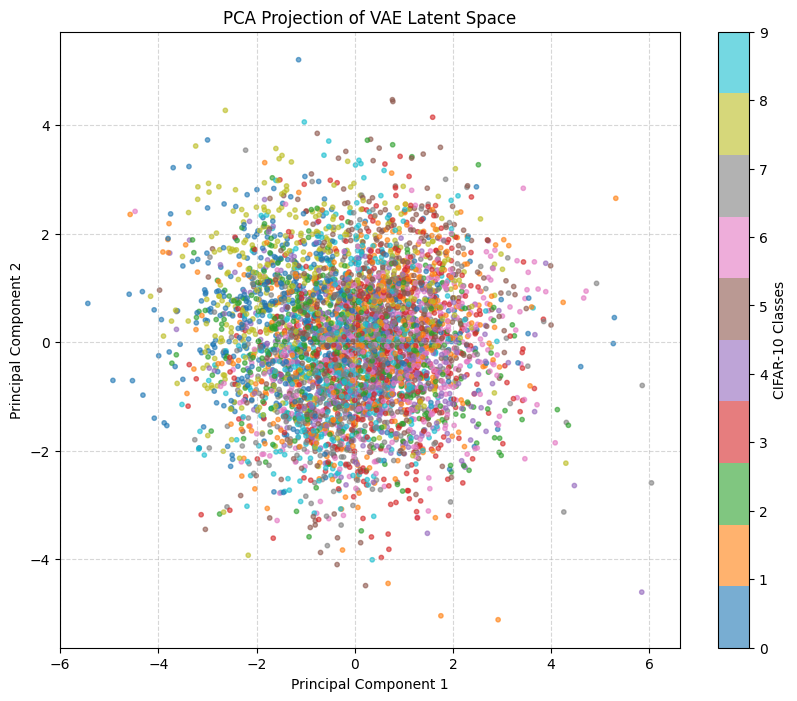

In [116]:
from sklearn.decomposition import PCA

def plot_latent_clusters(vae, x_data, y_data, max_samples=5000):
    # Subsample data for faster plotting if needed
    if len(x_data) > max_samples:
        indices = np.random.choice(len(x_data), max_samples, replace=False)
        x_data = x_data[indices]
        y_data = y_data[indices]

    # 1. Encode the validation/test images to get z_mean
    z_means, _, _ = vae.encoder.predict(x_data, verbose=0)

    # 2. Reduce 128D latent space down to 2D using PCA for visualization
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_means)

    # 3. Scatter plot colored by class labels
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_data, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, label="CIFAR-10 Classes")
    plt.title("PCA Projection of VAE Latent Space")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# Run it using your validation set and labels
# (Make sure y_val is your 1D integer label array, not the one-hot version)
plot_latent_clusters(vae, x_val, y_val)

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def plot_top_active_latent_grid(vae, x_val, latent_dim=128, n=15, scale=2.0, figsize=12):
    # 1. Automatically find the most active dimensions by checking variance
    z_means, _, _ = vae.encoder.predict(x_val, verbose=0)
    variances = np.var(z_means, axis=0)
    active_dims = np.argsort(variances)[::-1] # Sorted from highest variance to lowest
    
    dim1, dim2 = active_dims[0], active_dims[1]
    print(f"Using top active latent dimensions: {dim1} and {dim2}")

    image_size = 32  # CIFAR-10 image size
    figure = np.zeros((image_size * n, image_size * n, 3)) # RGB grid
    
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Create a latent vector filled with zeros, then modify the top active dimensions
            z_sample = np.zeros((1, latent_dim))
            z_sample[0, dim1] = xi
            z_sample[0, dim2] = yi
            
            # Predict using decoder -> output shape is (1, 32, 32, 3)
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0] 
            
            figure[
                i * image_size : (i + 1) * image_size,
                j * image_size : (j + 1) * image_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = image_size // 2
    end_range = n * image_size + start_range
    pixel_range = np.arange(start_range, end_range, image_size)
    
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))
    plt.xlabel(f"Latent Dimension {dim1} (Highest Variance)")
    plt.ylabel(f"Latent Dimension {dim2} (2nd Highest Variance)")
    plt.title("Active VAE Color Latent Space Grid")
    plt.imshow(figure)
    plt.show()

# Run it directly by passing your validation set
plot_top_active_latent_grid(vae, x_val, latent_dim=128, n=12, scale=2.0)

Using top active latent dimensions: 18 and 1


InvalidArgumentError: Graph execution error:

Detected at node 'decoder/dense_11/MatMul' defined at (most recent call last):
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\runpy.py", line 194, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\p2518031\.conda\envs\gpu_env\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "c:\Users\p2518031\.conda